# Platform MVP Market Research

This notebook summarizes market research for the first Vibe-to-MIDI MVP platform decision.

Decision target: which platform should be used for the first Vibe-to-MIDI MVP, what feature scope it should include, and where the competitive gap is.

## Research Scope

This research is limited to music-related apps and tools, including both production apps and learning apps.

Included:

- music production apps
- music learning apps
- ear training apps
- producer education apps
- DAWs and grooveboxes
- chord, scale, and theory apps
- MIDI generation/export tools
- sampler and synth apps
- music idea-capture apps
- browser-based music creation tools

Excluded:

- non-music productivity apps
- generic AI chat or image tools
- hardware-only products without an app/software workflow
- articles that are not tied to a usable music app/tool


## How To Run

Local setup from the repository root:

```bash
uv venv research/.venv
source research/.venv/bin/activate
uv pip install -r research/requirements.txt

JUPYTER_CONFIG_DIR=research/.jupyter \
JUPYTER_DATA_DIR=research/.jupyter-data \
JUPYTER_RUNTIME_DIR=research/.jupyter-runtime \
IPYTHONDIR=research/.ipython \
jupyter lab research/features/2026-05-10_android-mvp-market/notebooks/analysis.ipynb
```

If running in Google Colab, upload or clone the repository first.


## Research Hypothesis

### Idea

Evaluate whether the first Vibe-to-MIDI MVP should start on Web, iOS, or Android for vibe-to-DAW decision support.

### Target User

English-speaking electronic music beginners/intermediates making techno, house, ambient, minimal, or melodic techno.

### Problem

Users have a sound image, mood, movement, or emotion in mind, but do not know which notes, scales, chords, rhythms, or sound-design choices to use in a DAW.

### MVP Scope

- vibe tag selection
- generated audio preview
- scale/chord/bass/rhythm suggestions
- sound design hints
- copyable note/chord output

### Non-Goals

- full DAW
- generic AI music generator
- full MIDI export in phase 1
- cloud AI dependency

### Research Questions

- Is the direct competitor space crowded?
- Which platform is the best starting point: Web, iOS, or Android?
- What tradeoffs does each platform create for the first MVP?
- Should MIDI export be phase 1 or phase 2?
- Is English-first acceptable?


## Source Notes

Sources were checked on 2026-05-10. This notebook keeps source notes concise and link-oriented. Only music-related apps/tools are included.

### Web tools

- Voxtura, ChordGen, GenChords, Veena Studio, MIDY, Chordoo, Melossist, and Hookpad show that web-based chord/MIDI generation and theory-assisted songwriting are already crowded.
- Several web tools already offer mood/vibe prompts and MIDI export. This weakens a generic web AI-chord-generator positioning.

### iOS tools

- iOS has strong production apps and theory/chord tools: GarageBand, Ableton Note, Auxy, Groovebox, Scaler, TONALY, OtoTheory, Chord Progression Generator, n-Track, Mighty Synth Sampler, and SunVox.
- iOS has stronger polished music-making references than Android, especially for make-first workflows.

### Android tools

- Android has serious production tools: FL Studio Mobile, G-Stomper Studio, Cubasis 3, n-Track Studio, SunVox, Walk Band, BandLab, Koala Sampler, Chordbot, and AI Chord Generator.
- Android has fewer polished vibe-to-theory / vibe-to-DAW assistant examples than web and iOS. This supports an Android wedge, but the MVP must avoid becoming just another DAW or chord generator.


## Source URLs

- https://voxtura.ai/
- https://www.chordgen.org/
- https://www.chordoo.com/
- https://www.melossist.com/
- https://www.genchords.com/
- https://www.veena.studio/features/ai-chord-progression
- https://midy.nighthink.com/
- https://www.hooktheory.com/hookpad
- https://apps.apple.com/us/app/chord-progression-generator/id1339399661
- https://apps.apple.com/us/app/ototheory/id6755084287
- https://apps.apple.com/us/app/tonaly-songs-scales-theory/id1242467844
- https://apps.apple.com/us/app/scaler-2/id1603180235
- https://apps.apple.com/us/app/garageband/id408709785
- https://apps.apple.com/us/app/ableton-note/id1633243177
- https://apps.apple.com/us/app/auxy-studio/id1034348186
- https://apps.apple.com/us/app/groovebox-beat-synth-studio/id1242847278
- https://apps.apple.com/us/app/n-track-studio-pro-daw/id1160793386
- https://apps.apple.com/us/app/mighty-synth-sampler/id6445898095
- https://apps.apple.com/us/app/sunvox/id324462544
- https://play.google.com/store/apps/details?id=com.brave.chord.generator
- https://play.google.com/store/apps/details?id=com.chordbot
- https://play.google.com/store/apps/details?id=com.imageline.FLM
- https://play.google.com/store/apps/details?id=com.bandlab.bandlab
- https://play.google.com/store/apps/details?id=com.elf.koalasampler
- https://play.google.com/store/apps/details?id=com.planeth.gstomper
- https://play.google.com/store/apps/details?id=com.ntrack.studio.demo
- https://play.google.com/store/apps/details?id=nightradio.sunvox
- https://play.google.com/store/apps/details?id=com.gamestar.pianoperfect
- https://play.google.com/store/apps/details?id=com.steinberg.cubasis3


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

FEATURE_SLUG = "2026-05-10_android-mvp-market"

def find_feature_dir(start: Path) -> Path:
    for base in [start, *start.parents]:
        candidate = base / "research" / "features" / FEATURE_SLUG
        if (candidate / "notebooks" / "analysis.ipynb").exists():
            return candidate
        if base.name == FEATURE_SLUG and (base / "notebooks" / "analysis.ipynb").exists():
            return base
    return start

FEATURE_DIR = find_feature_dir(Path.cwd().resolve())
FIGURES_DIR = FEATURE_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

competitors = pd.DataFrame([{'android_support': 'no',
  'category': 'ai_chord_generator',
  'core_promise': 'Natural-language AI chord progression generator with synth preview and MIDI/WAV export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'web-first; chord-centric; likely external AI dependency; not Android-native',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'Voxtura',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'freemium',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official page describes natural language prompts, synth preview, effects, MIDI export.',
  'source_url': 'https://voxtura.ai/',
  'strengths': 'plain-English vibe prompts; MIDI export; built-in synths/effects; DAW workflow',
  'target_user': 'music producers',
  'vibe_mapping': 'yes',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'ai_chord_generator',
  'core_promise': 'Describe a mood and get chord progressions with MIDI download.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'web-first; harmony-focused; no mobile app workflow',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'ChordGen',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'free',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official page says describe a mood, generate progressions, download MIDI.',
  'source_url': 'https://www.chordgen.org/',
  'strengths': 'mood prompt; visual piano; edit/refine; free MIDI export',
  'target_user': 'songwriters and producers',
  'vibe_mapping': 'yes',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'chord_generator',
  'core_promise': 'Generate genre chord progressions and export MIDI.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'less mood/vibe-specific; chord-only; no mobile-native app',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'Chordoo',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'free',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official page covers Pop/EDM/Lo-fi and MIDI export.',
  'source_url': 'https://www.chordoo.com/',
  'strengths': 'free MIDI export; genre presets; no signup; DAW wording',
  'target_user': 'producers needing quick chord progressions',
  'vibe_mapping': 'partial',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'midi_generator',
  'core_promise': 'MIDI generator, chord progression creator, MIDI analyzer, and genre track generator.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'broad MIDI utility rather than mobile vibe-to-DAW learning',
  'ios_support': 'no',
  'learning_flow': 'mixed',
  'make_first_learning': 'no',
  'midi_export': 'yes',
  'name': 'Melossist',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'free_support',
  'product_mode': 'production_only',
  'source_note': 'Official page lists MIDI generator/analyzer, chord creator, genre generator.',
  'source_url': 'https://www.melossist.com/',
  'strengths': 'MIDI analysis; genre track generation; ambient/EDM coverage',
  'target_user': 'producers and composers',
  'vibe_mapping': 'partial',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'ai_chord_generator',
  'core_promise': 'Prompt the vibe, audition variations, and drag MIDI into a DAW.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'web-first; chord-centric; not Android-native',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'GenChords',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'unknown',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official page messaging centers vibe prompts and MIDI workflow.',
  'source_url': 'https://www.genchords.com/',
  'strengths': 'explicit vibe prompt; DAW-ready MIDI; positioned as inspiration not autopilot',
  'target_user': 'producers and songwriters',
  'vibe_mapping': 'yes',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'ai_chord_generator',
  'core_promise': 'Generate editable MIDI chord sequences from genre, mood, and key prompts.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'web-first; chord-focused; not Android-native',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'Veena Studio AI Chord Progression',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'freemium',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official page says browser-based harmony tool creates editable MIDI matched to genre/mood/key.',
  'source_url': 'https://www.veena.studio/features/ai-chord-progression',
  'strengths': 'mood prompt; editable MIDI; DAW timeline metaphor',
  'target_user': 'browser-based producers',
  'vibe_mapping': 'yes',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'ai_midi_generator',
  'core_promise': 'Generate melodies, chords, and arpeggios with mood controls and MIDI download.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'generator more than learning assistant; limited sound-design guidance',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'MIDY',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'free',
  'product_mode': 'production_only',
  'source_note': 'Official page presents mood-controlled AI MIDI generation.',
  'source_url': 'https://midy.nighthink.com/',
  'strengths': 'mood/instrument/tempo/length controls; MIDI download',
  'target_user': 'producers with beat block',
  'vibe_mapping': 'partial',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'songwriting_theory_tool',
  'core_promise': 'Music-theory-assisted sketchpad for chords, melodies, beats, and MIDI export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'larger-screen web flow; theory-forward; not Android-native; less club-sound-specific',
  'ios_support': 'partial',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'no',
  'midi_export': 'yes',
  'name': 'Hookpad',
  'platform_group': 'web',
  'platforms': 'web/tablet',
  'pricing': 'freemium',
  'product_mode': 'learning_only',
  'source_note': 'Official page describes music theory sketchpad and drag-and-drop MIDI to DAWs.',
  'source_url': 'https://www.hooktheory.com/hookpad',
  'strengths': 'smart chord palettes; melody support; MIDI export; large theory/song database context',
  'target_user': 'songwriters learning theory while composing',
  'vibe_mapping': 'no',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'ios_chord_generator',
  'core_promise': 'Generate chords and export chord/bass MIDI files to a DAW.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'iOS-only; chord progression tool rather than sound-design assistant',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'Chord Progression Generator',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'freemium',
  'product_mode': 'production_plus_learning',
  'source_note': 'App Store page mentions EDM bedroom producers and MIDI export with chord/bass files.',
  'source_url': 'https://apps.apple.com/us/app/chord-progression-generator/id1339399661',
  'strengths': 'explicit EDM positioning; MIDI export; bassline export; strong App Store ratings',
  'target_user': 'EDM bedroom producers and musicians',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_chord_theory_tool',
  'core_promise': 'Chord progression builder with scale analysis, AI import, and MIDI export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'guitar/fretboard leaning; not club/electronic-specific; not Android-native',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'OtoTheory / AI Chord Assistant',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'freemium',
  'product_mode': 'production_plus_learning',
  'source_note': 'App Store page says no theory required, scale analysis, MIDI export for DAWs.',
  'source_url': 'https://apps.apple.com/us/app/ototheory/id6755084287',
  'strengths': 'no-theory positioning; scale analysis; DAW-ready MIDI export; DTM workflow',
  'target_user': 'guitarists, DTM users, songwriters',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_theory_songwriting',
  'core_promise': 'Circle-of-fifths songwriting, scales, theory, and MIDI export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'more theory-forward; less immediate electronic sound preview; not Android-native',
  'ios_support': 'yes',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'no',
  'midi_export': 'yes',
  'name': 'TONALY',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad/Mac',
  'pricing': 'freemium',
  'product_mode': 'learning_only',
  'source_note': 'App Store page describes circle of fifths, scales, MIDI export, visual theory.',
  'source_url': 'https://apps.apple.com/us/app/tonaly-songs-scales-theory/id1242467844',
  'strengths': 'visual theory; MIDI/PDF export; strong ratings; multiple instruments',
  'target_user': 'songwriters, producers, musicians learning theory',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_theory_composition_workstation',
  'core_promise': 'Detect key/scale and suggest chords, melodies, basslines, genre and mood chord sets.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'iPad-only legacy version; deep workstation complexity; not Android-native',
  'ios_support': 'yes',
  'learning_flow': 'mixed',
  'make_first_learning': 'no',
  'midi_export': 'yes',
  'name': 'Scaler 2 iPad',
  'platform_group': 'ios',
  'platforms': 'iPad',
  'pricing': 'freemium',
  'product_mode': 'production_plus_learning',
  'source_note': 'App Store page lists mood-based chord sets, basslines, melodies, MIDI export.',
  'source_url': 'https://apps.apple.com/us/app/scaler-2/id1603180235',
  'strengths': 'MIDI/audio detection; mood-based chord sets; bassline/melody generation; MIDI export; AUv3',
  'target_user': 'composers and producers needing chord/melody ideas',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_daw',
  'core_promise': 'Touch instruments, Live Loops, recording studio, loops, and sound packs.',
  'daw_output': 'partial',
  'electronic_music_fit': 'medium',
  'gaps': 'does not solve which notes/scales/chords to choose; Apple-only',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'GarageBand iOS',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'free',
  'product_mode': 'production_only',
  'source_note': 'App Store page describes Touch Instruments, Live Loops, Sound Library, recording studio.',
  'source_url': 'https://apps.apple.com/us/app/garageband/id408709785',
  'strengths': 'mass-market accessibility; touch instruments; Live Loops; recording up to 32 tracks',
  'target_user': 'general mobile music creators',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_idea_capture',
  'core_promise': 'Start musical ideas, sample, sequence MIDI, and send projects to Ableton Live.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'iOS-only; not a theory or note-choice assistant; DAW ecosystem-specific',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'Ableton Note',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'paid_iap',
  'product_mode': 'production_only',
  'source_note': 'App Store page describes MIDI editor, curated sounds, sampling, and sending projects to Live.',
  'source_url': 'https://apps.apple.com/us/app/ableton-note/id1633243177',
  'strengths': 'idea capture; curated sounds; MIDI editor; Ableton Cloud/Live continuation',
  'target_user': 'Ableton Live users and mobile idea sketchers',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_loop_production',
  'core_promise': 'Draw notes and drum patterns, arrange loops, shape sounds, export stems/projects/MIDI.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'iOS-first; not a theory explanation assistant; subscription model',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'Auxy Studio',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'freemium_subscription',
  'product_mode': 'production_only',
  'source_note': 'App Store page describes drawing notes, electronic music, stems/project export; editor note mentions '
                 'MIDI export.',
  'source_url': 'https://apps.apple.com/us/app/auxy-studio/id1034348186',
  'strengths': 'simple grid flow; strong electronic fit; exports; low-friction idea capture',
  'target_user': 'modern beat and electronic music creators',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_groovebox',
  'core_promise': 'Synth/drum studio with patterns, key/scale modes, Ableton Link and Ableton Export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'iOS-only; pattern/sound tool, not vibe-to-theory assistant',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'Groovebox',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'freemium_iap',
  'product_mode': 'production_only',
  'source_note': 'App Store page lists key/scale modes, Ableton Link, Ableton Export, synths/drum machines.',
  'source_url': 'https://apps.apple.com/us/app/groovebox-beat-synth-studio/id1242847278',
  'strengths': 'touch instruments; patterns; scale modes; Ableton export; electronic orientation',
  'target_user': 'electronic music makers',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'partial',
  'category': 'ios_daw',
  'core_promise': 'Audio and MIDI multitrack recorder with step sequencer, instruments, effects, export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'general DAW, not decision assistant; less focused on club theory/sound choice',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'n-Track Studio Pro iOS',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'paid_iap',
  'product_mode': 'production_only',
  'source_note': 'App Store page describes audio/MIDI tracks, step sequencer, instruments, effects, export.',
  'source_url': 'https://apps.apple.com/us/app/n-track-studio-pro-daw/id1160793386',
  'strengths': 'full DAW; MIDI tracks; step sequencer; virtual instruments; export options',
  'target_user': 'mobile recording and beat-making users',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_synth_sampler',
  'core_promise': 'Synth, sampler, AUv3 plugins, MIDI processor, play surfaces, sound packs.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'sound creation tool, not chord/rhythm decision assistant; iOS/Mac ecosystem',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'Mighty Synth Sampler',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad/Mac',
  'pricing': 'freemium_iap',
  'product_mode': 'production_only',
  'source_note': 'App Store page describes synth/sampler, MIDI CC, AUv3 plugins, effects.',
  'source_url': 'https://apps.apple.com/us/app/mighty-synth-sampler/id6445898095',
  'strengths': 'AUv3; MIDI support; synth/sampler; play surfaces; sound design depth',
  'target_user': 'mobile synth/sampler musicians',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'ios_tracker_modular',
  'core_promise': 'Modular synth, tracker sequencer, MIDI import/export, AUv3.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'steep learning curve; not beginner/vibe-oriented; no guided DAW choices',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'SunVox iOS',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'paid',
  'product_mode': 'production_only',
  'source_note': 'App Store page describes modular synth, MIDI sequencer/tracker, MIDI import/export.',
  'source_url': 'https://apps.apple.com/us/app/sunvox/id324462544',
  'strengths': 'powerful modular/tracker; MIDI import/export; microtonal sequencer; AUv3',
  'target_user': 'advanced modular/tracker musicians',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_ai_chord_generator',
  'core_promise': 'AI chord progressions, melodies, piano-roll preview, and MIDI files.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'smaller/unclear traction; generic chord framing; AI dependency unclear',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'AI Chord Generator',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'ads',
  'product_mode': 'production_plus_learning',
  'source_note': 'Google Play page positions around AI chord progressions, melodies, piano roll and MIDI.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.brave.chord.generator',
  'strengths': 'Android-native; mood/key/scale; piano roll; MIDI export',
  'target_user': 'beginner and advanced producers',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_chord_arranger',
  'core_promise': 'Create and play complex chord progressions and export MIDI.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'not vibe-first; not electronic sound-design focused; traditional chord workflow',
  'ios_support': 'partial',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'Chordbot',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'paid',
  'product_mode': 'production_only',
  'source_note': 'Google Play listing used in initial research; chord progression and MIDI export baseline.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.chordbot',
  'strengths': 'Android-native; MIDI export; arrangement patterns; established tool',
  'target_user': 'musicians experimenting with chord progressions',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_daw',
  'core_promise': 'Complete multitrack music projects with piano roll, synths, sampler, MIDI import/export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'does not solve what notes/chords/scales to choose; production environment, not assistant',
  'ios_support': 'partial',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'FL Studio Mobile',
  'platform_group': 'android',
  'platforms': 'Android/ChromeOS',
  'pricing': 'paid_iap',
  'product_mode': 'production_only',
  'source_note': 'Google Play page lists multitrack projects, synths/sampler, piano roll, MIDI import/export.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.imageline.FLM',
  'strengths': 'full mobile DAW; MIDI import/export; piano roll; synths/samplers; large install base',
  'target_user': 'mobile music producers',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_daw_social',
  'core_promise': 'Mobile DAW, virtual instruments, presets, AI tools, collaboration and distribution.',
  'daw_output': 'partial',
  'electronic_music_fit': 'medium',
  'gaps': 'broad studio, not vibe-to-note assistant; privacy/data footprint; less niche electronic guidance',
  'ios_support': 'partial',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'BandLab Android',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'freemium_iap',
  'product_mode': 'production_only',
  'source_note': 'Google Play page cites 100M+ creators, virtual instruments, presets, AI tools.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.bandlab.bandlab',
  'strengths': 'huge reach; free mobile DAW; instruments; AI tools; collaboration/social layer',
  'target_user': 'broad music creators',
  'vibe_mapping': 'no',
  'web_support': 'yes'},
 {'android_support': 'yes',
  'category': 'android_sampler',
  'core_promise': 'Fast pocket sampler for recording/importing sounds, sequencing beats, FX, scales, and MIDI control.',
  'daw_output': 'partial',
  'electronic_music_fit': 'high',
  'gaps': 'sample/beat focused; not harmony/vibe-to-MIDI assistant',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'Koala Sampler Android',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'paid_iap',
  'product_mode': 'production_only',
  'source_note': 'Google Play page emphasizes instant flow, scale mode, swing, MIDI controllable, WAV export.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.elf.koalasampler',
  'strengths': 'very fast flow; sampler-first; scales/swing; MIDI control; strong electronic/beat fit',
  'target_user': 'beatmakers and sample-based creators',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_groovebox',
  'core_promise': 'Step-sequencer groovebox, sampler, VA synth, Ableton Link, MIDI integration, MIDI/WAV export.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'complex production tool, not beginner decision assistant; Android-only',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'G-Stomper Studio',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'paid',
  'product_mode': 'production_only',
  'source_note': 'Google Play page lists groovebox, sampler, VA synth, Ableton Link, MIDI in/out/export.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.planeth.gstomper',
  'strengths': 'Android electronic powerhouse; MIDI in/out; Ableton Link; pattern MIDI export; sound design',
  'target_user': 'electronic live performance and groovebox users',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_daw',
  'core_promise': 'Audio, instrument and beat tracks with loops, step sequencer, virtual instruments, MIDI keyboards.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'general DAW; not focused on note/chord choice or vibe mapping',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'n-Track Studio Android',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'freemium_subscription',
  'product_mode': 'production_only',
  'source_note': 'Google Play page describes Android music production studio with instruments, beat tracks, MIDI '
                 'keyboards.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.ntrack.studio.demo',
  'strengths': 'Android DAW; audio/instrument/beat tracks; loops; virtual instruments; large installs',
  'target_user': 'mobile recording and beat-making users',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_tracker_modular',
  'core_promise': 'Modular synth/tracker with microtonal sequencer, MIDI import/export, USB MIDI, generative features.',
  'daw_output': 'yes',
  'electronic_music_fit': 'high',
  'gaps': 'steep learning curve; not a guided learning/decision app',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'yes',
  'name': 'SunVox Android',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'paid',
  'product_mode': 'production_only',
  'source_note': 'Google Play page lists modular synth, tracker, MIDI import/export, generative features.',
  'source_url': 'https://play.google.com/store/apps/details?id=nightradio.sunvox',
  'strengths': 'advanced synthesis; MIDI import/export; generative tools; Android/iOS parity',
  'target_user': 'advanced modular/tracker musicians',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_virtual_instruments',
  'core_promise': 'Virtual instruments, multitrack mixer, MIDI recording/editing, piano roll, USB MIDI support.',
  'daw_output': 'partial',
  'electronic_music_fit': 'low',
  'gaps': 'instrument toolkit rather than vibe-to-DAW assistant; less professional electronic positioning',
  'ios_support': 'no',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'Walk Band',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'ads_iap',
  'product_mode': 'production_only',
  'source_note': 'Google Play page lists virtual instruments, MIDI track recording/editing, piano roll, USB MIDI.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.gamestar.pianoperfect',
  'strengths': 'large install base; virtual instruments; MIDI editing; accessible Android entry point',
  'target_user': 'casual mobile music makers and learners',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_daw',
  'core_promise': 'Mobile DAW with audio and MIDI editor, automation, pads, keyboard, instruments and effects.',
  'daw_output': 'yes',
  'electronic_music_fit': 'medium',
  'gaps': 'DAW not assistant; high price; does not guide vibe-to-scale/chord choices',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'partial',
  'midi_export': 'partial',
  'name': 'Cubasis 3 Android',
  'platform_group': 'android',
  'platforms': 'Android/ChromeOS',
  'pricing': 'paid_iap',
  'product_mode': 'production_only',
  'source_note': 'Google Play page calls it a complete audio/MIDI DAW with beat and chord creation.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.steinberg.cubasis3',
  'strengths': 'complete Android DAW; audio/MIDI editor; beat/chord pads; professional positioning',
  'target_user': 'mobile DAW users needing audio/MIDI editing',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'partial',
  'category': 'web_interactive_music_learning',
  'core_promise': 'Interactive browser lessons for beats, notes, scales, chords, basslines, melodies, and song '
                  'structure.',
  'daw_output': 'no',
  'electronic_music_fit': 'high',
  'gaps': 'not a mobile app; not DAW-ready output; not personalized vibe-to-DAW guidance',
  'ios_support': 'partial',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'yes',
  'midi_export': 'no',
  'name': 'Ableton Learning Music',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'free',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official Ableton interactive music-learning website for beats, basslines, melodies, scales, chords, '
                 'and song structure.',
  'source_url': 'https://learningmusic.ableton.com/',
  'strengths': 'hands-on browser learning; make-first exercises; strong production context; no install friction',
  'target_user': 'beginners learning music creation in a browser',
  'vibe_mapping': 'partial',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'synth_sound_design_learning',
  'core_promise': 'Learn synthesis by programming patches by ear with interactive challenges and a built-in synth.',
  'daw_output': 'partial',
  'electronic_music_fit': 'high',
  'gaps': 'synthesis only; not chord/scale/rhythm assistant; iPad/desktop rather than Android-first',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'yes',
  'midi_export': 'no',
  'name': 'Syntorial',
  'platform_group': 'web',
  'platforms': 'web/iPad/desktop',
  'pricing': 'freemium_paid',
  'product_mode': 'production_plus_learning',
  'source_note': 'Official page emphasizes learn-by-doing, all-by-ear synth programming challenges with a built-in '
                 'synth.',
  'source_url': 'https://www.syntorial.com/',
  'strengths': 'strong make-first learning; sound-design specific; built-in synth; production-relevant ear training',
  'target_user': 'musicians and producers learning synthesis',
  'vibe_mapping': 'partial',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'ios_synth_sound_design_learning',
  'core_promise': 'Interactive synthesizer training app that teaches users to program patches by ear.',
  'daw_output': 'partial',
  'electronic_music_fit': 'high',
  'gaps': 'iPad-only; focused on timbre not DAW note/chord/rhythm decisions',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'yes',
  'midi_export': 'no',
  'name': 'Syntorial 2 iPad',
  'platform_group': 'ios',
  'platforms': 'iPad',
  'pricing': 'freemium_iap',
  'product_mode': 'production_plus_learning',
  'source_note': 'App Store page describes synth training through video demos, interactive challenges, and built-in '
                 'soft synth.',
  'source_url': 'https://apps.apple.com/us/app/syntorial-2/id6448928707',
  'strengths': 'iPad-native; interactive challenges; very close to hear-sound-in-head -> make-sound flow',
  'target_user': 'iPad musicians learning synth programming',
  'vibe_mapping': 'partial',
  'web_support': 'no'},
 {'android_support': 'partial',
  'category': 'producer_audio_ear_training',
  'core_promise': 'Audio ear training games for frequency, compression, panning, space, and mixing skills.',
  'daw_output': 'no',
  'electronic_music_fit': 'high',
  'gaps': 'mixing/ear training, not composition; not vibe-to-scale/chord/rhythm assistant',
  'ios_support': 'partial',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'partial',
  'midi_export': 'no',
  'name': 'SoundGym',
  'platform_group': 'web',
  'platforms': 'web',
  'pricing': 'freemium_subscription',
  'product_mode': 'learning_only',
  'source_note': 'Official page frames SoundGym as audio ear training for music producers and sound engineers.',
  'source_url': 'https://www.soundgym.co/',
  'strengths': 'producer-specific learning; gamified; progress tracking; production/mixing context',
  'target_user': 'music producers and sound engineers',
  'vibe_mapping': 'no',
  'web_support': 'yes'},
 {'android_support': 'no',
  'category': 'instrument_performance_learning',
  'core_promise': 'Interactive lessons for drums, MIDI keyboard, and finger drumming with real-time feedback.',
  'daw_output': 'no',
  'electronic_music_fit': 'high',
  'gaps': 'performance skill learning rather than composition decision assistant; iPad/desktop focus',
  'ios_support': 'yes',
  'learning_flow': 'make_to_learn',
  'make_first_learning': 'yes',
  'midi_export': 'no',
  'name': 'Melodics for iPad',
  'platform_group': 'ios',
  'platforms': 'iPad/desktop',
  'pricing': 'freemium_subscription',
  'product_mode': 'production_plus_learning',
  'source_note': 'App Store page describes interactive lessons for drums, MIDI keyboard, and finger drumming with '
                 'feedback.',
  'source_url': 'https://apps.apple.com/us/app/melodics-for-ipad/id1474895145',
  'strengths': 'producer-relevant performance learning; hands-on play; pad/controller workflow; strong rhythm angle',
  'target_user': 'producers learning pads, keys, and finger drumming',
  'vibe_mapping': 'no',
  'web_support': 'partial'},
 {'android_support': 'yes',
  'category': 'ear_training_music_theory_learning',
  'core_promise': 'Ear training, rhythm training, solfege, music theory, and sight reading lessons.',
  'daw_output': 'no',
  'electronic_music_fit': 'medium',
  'gaps': 'lesson/training-first; not production-specific; not DAW-ready output',
  'ios_support': 'yes',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'no',
  'midi_export': 'no',
  'name': 'Perfect Ear',
  'platform_group': 'ios_android',
  'platforms': 'iOS/Android',
  'pricing': 'freemium_iap',
  'product_mode': 'learning_only',
  'source_note': 'App Store page describes ear training, rhythm training, solfege, music theory, note reading.',
  'source_url': 'https://apps.apple.com/us/app/perfect-ear-music-rhythm/id1440768353',
  'strengths': 'broad music learning; custom exercises; scales/chords/intervals; available mobile ecosystem',
  'target_user': 'musicians learning ear training, rhythm, solfege, and theory',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'android_ear_training_learning',
  'core_promise': 'Progressive ear training drills for intervals, chords, scales, dictation, and chord progressions.',
  'daw_output': 'no',
  'electronic_music_fit': 'medium',
  'gaps': 'training-first; not production workflow; no DAW-ready output',
  'ios_support': 'no',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'no',
  'midi_export': 'no',
  'name': 'Complete Ear Trainer',
  'platform_group': 'android',
  'platforms': 'Android',
  'pricing': 'freemium_iap',
  'product_mode': 'learning_only',
  'source_note': 'Google Play page describes progressive drills, intervals, chords, scales, dictation, theory cards.',
  'source_url': 'https://play.google.com/store/apps/details?id=com.binaryguilt.completeeartrainer',
  'strengths': 'Android-native; structured curriculum; gamified progression; strong learning depth',
  'target_user': 'musicians developing relative pitch and theory knowledge',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'yes',
  'category': 'functional_ear_training_learning',
  'core_promise': 'Ear training focused on hearing notes by musical function rather than isolated intervals.',
  'daw_output': 'no',
  'electronic_music_fit': 'medium',
  'gaps': 'ear-training only; no production workflow or DAW output; not vibe-based',
  'ios_support': 'yes',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'no',
  'midi_export': 'no',
  'name': 'Functional Ear Trainer',
  'platform_group': 'ios_android',
  'platforms': 'iOS/Android',
  'pricing': 'freemium_iap',
  'product_mode': 'learning_only',
  'source_note': 'App Store page explains ear training for transcribing, composing, improvising, and hearing notes by '
                 'meaning/function.',
  'source_url': 'https://apps.apple.com/us/app/functional-ear-trainer/id1088761926',
  'strengths': 'clear learning niche; strong ratings; directly tied to composing/improvising/transcribing',
  'target_user': 'musicians learning to hear tonal function and transcribe/play by ear',
  'vibe_mapping': 'no',
  'web_support': 'no'},
 {'android_support': 'no',
  'category': 'ios_music_theory_learning',
  'core_promise': 'Customizable theory exercises and calculators for notes, intervals, scales, chords, and analysis.',
  'daw_output': 'no',
  'electronic_music_fit': 'low',
  'gaps': 'quiz/tool-first; not production-specific; no sound-image to DAW guidance',
  'ios_support': 'yes',
  'learning_flow': 'learn_to_make',
  'make_first_learning': 'no',
  'midi_export': 'no',
  'name': 'Tenuto',
  'platform_group': 'ios',
  'platforms': 'iPhone/iPad',
  'pricing': 'paid',
  'product_mode': 'learning_only',
  'source_note': 'App Store page describes 24 exercises plus calculators for notes, intervals, scales, chords, and '
                 'analysis.',
  'source_url': 'https://apps.apple.com/us/app/tenuto/id459313476',
  'strengths': 'deep theory practice; compact app; strong music theory reference; exercises and calculators',
  'target_user': 'music theory students and self-learners',
  'vibe_mapping': 'no',
  'web_support': 'partial'}])
keywords = pd.DataFrame([{'intent': 'direct concept',
  'keyword': 'vibe to midi',
  'language': 'en',
  'notes': 'Likely niche phrase; validate search volume.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'direct concept',
  'keyword': 'mood to midi',
  'language': 'en',
  'notes': 'Core product language candidate.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'solution aware',
  'keyword': 'AI chord progression generator',
  'language': 'en',
  'notes': 'Crowded web competitor space.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'competitive'},
 {'intent': 'solution aware',
  'keyword': 'chord progression generator MIDI',
  'language': 'en',
  'notes': 'Common existing workflow.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'competitive'},
 {'intent': 'problem aware',
  'keyword': 'music theory for producers',
  'language': 'en',
  'notes': 'Learning-oriented angle.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'stable'},
 {'intent': 'genre specific',
  'keyword': 'techno bassline generator',
  'language': 'en',
  'notes': 'Useful for club music positioning.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'genre specific',
  'keyword': 'melodic techno chords',
  'language': 'en',
  'notes': 'Likely content/MVP tag candidate.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'problem aware',
  'keyword': 'how to make dark techno',
  'language': 'en',
  'notes': 'Maps to dark/underground tag.',
  'region': 'global',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'problem aware',
  'keyword': 'DTM コード進行',
  'language': 'ja',
  'notes': 'Japanese secondary market keyword.',
  'region': 'jp',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'pain expression',
  'keyword': '作曲 コード わからない',
  'language': 'ja',
  'notes': 'Direct pain phrasing.',
  'region': 'jp',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'},
 {'intent': 'genre specific',
  'keyword': 'メロディックテクノ コード',
  'language': 'ja',
  'notes': 'Japanese club music niche.',
  'region': 'jp',
  'relative_interest': '',
  'source': 'manual_seed',
  'trend_direction': 'unknown'}])

print(FEATURE_DIR)
competitors.head()


/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-10_android-mvp-market


,android_support,category,core_promise,daw_output,electronic_music_fit,gaps,ios_support,learning_flow,make_first_learning,midi_export,...,platform_group,platforms,pricing,product_mode,source_note,source_url,strengths,target_user,vibe_mapping,web_support
0,no,ai_chord_generator,Natural-language AI chord progression generato...,yes,high,web-first; chord-centric; likely external AI d...,no,make_to_learn,partial,yes,...,web,web,freemium,production_plus_learning,Official page describes natural language promp...,https://voxtura.ai/,plain-English vibe prompts; MIDI export; built...,music producers,yes,yes
1,no,ai_chord_generator,Describe a mood and get chord progressions wit...,yes,medium,web-first; harmony-focused; no mobile app work...,no,make_to_learn,partial,yes,...,web,web,free,production_plus_learning,"Official page says describe a mood, generate p...",https://www.chordgen.org/,mood prompt; visual piano; edit/refine; free M...,songwriters and producers,yes,yes
2,no,chord_generator,Generate genre chord progressions and export M...,yes,medium,less mood/vibe-specific; chord-only; no mobile...,no,make_to_learn,partial,yes,...,web,web,free,production_plus_learning,Official page covers Pop/EDM/Lo-fi and MIDI ex...,https://www.chordoo.com/,free MIDI export; genre presets; no signup; DA...,producers needing quick chord progressions,partial,yes
3,no,midi_generator,"MIDI generator, chord progression creator, MID...",yes,high,broad MIDI utility rather than mobile vibe-to-...,no,mixed,no,yes,...,web,web,free_support,production_only,"Official page lists MIDI generator/analyzer, c...",https://www.melossist.com/,MIDI analysis; genre track generation; ambient...,producers and composers,partial,yes
4,no,ai_chord_generator,"Prompt the vibe, audition variations, and drag...",yes,medium,web-first; chord-centric; not Android-native,no,make_to_learn,partial,yes,...,web,web,unknown,production_plus_learning,Official page messaging centers vibe prompts a...,https://www.genchords.com/,explicit vibe prompt; DAW-ready MIDI; position...,producers and songwriters,yes,yes


In [2]:
# music_scope_validation
allowed_categories = (
    competitors["category"].str.contains("daw|groovebox|chord|theory|midi|sampler|synth|tracker|idea|songwriting|production|virtual|learning|training|performance|ear", regex=True)
)
assert allowed_categories.all(), competitors.loc[~allowed_categories, ["name", "category"]]
print(f"Music-related apps/tools in scope: {len(competitors)} / {len(competitors)}")


Music-related apps/tools in scope: 38 / 38


## Dataset Snapshot

In [3]:
summary = pd.DataFrame({
    "metric": [
        "competitors_reviewed",
        "web_primary",
        "ios_primary",
        "android_primary",
        "android_support_yes",
        "ios_support_yes",
        "web_support_yes",
        "daw_output_yes",
        "midi_export_yes",
        "vibe_mapping_yes",
        "vibe_mapping_partial",
    ],
    "value": [
        len(competitors),
        (competitors["platform_group"] == "web").sum(),
        (competitors["platform_group"] == "ios").sum(),
        (competitors["platform_group"] == "android").sum(),
        (competitors["android_support"] == "yes").sum(),
        (competitors["ios_support"] == "yes").sum(),
        (competitors["web_support"] == "yes").sum(),
        (competitors["daw_output"] == "yes").sum(),
        (competitors["midi_export"] == "yes").sum(),
        (competitors["vibe_mapping"] == "yes").sum(),
        (competitors["vibe_mapping"] == "partial").sum(),
    ]
})
summary


,metric,value
0,competitors_reviewed,38
1,web_primary,11
2,ios_primary,14
3,android_primary,11
4,android_support_yes,14
5,ios_support_yes,21
6,web_support_yes,12
7,daw_output_yes,25
8,midi_export_yes,19
9,vibe_mapping_yes,4


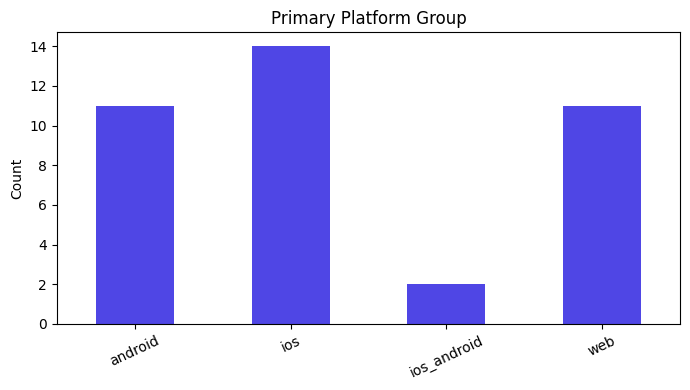

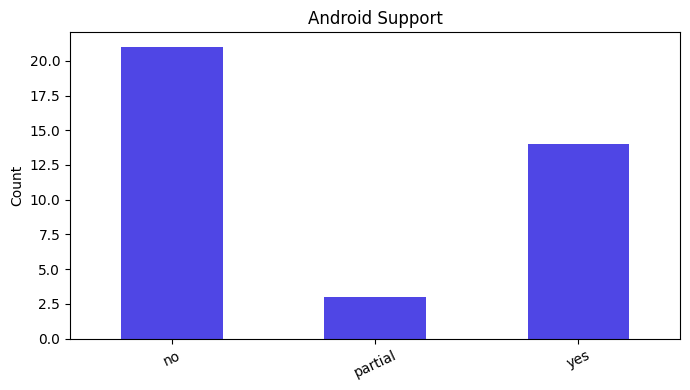

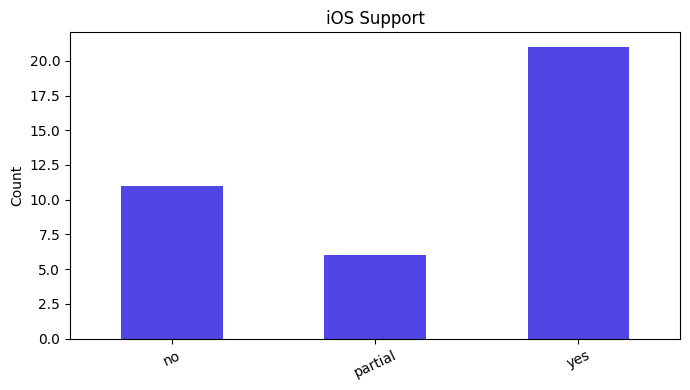

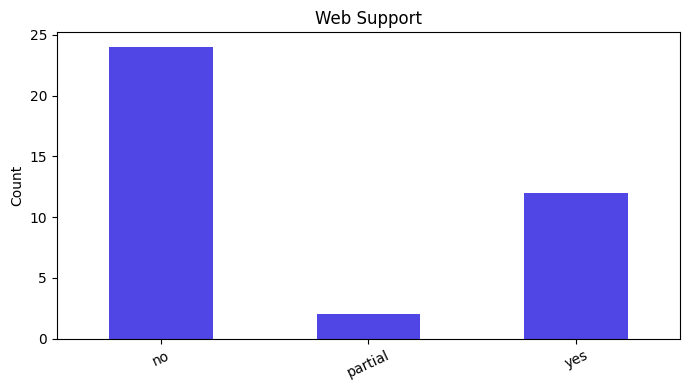

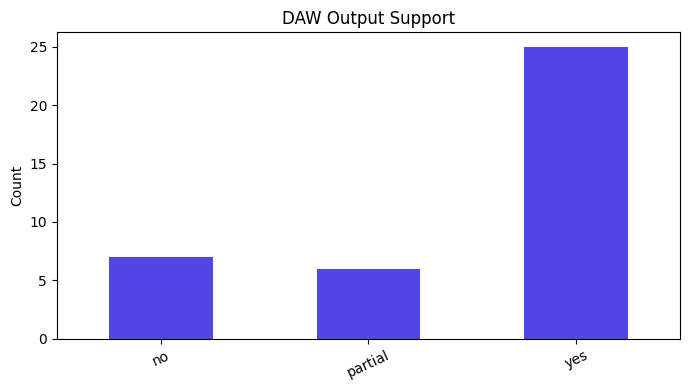

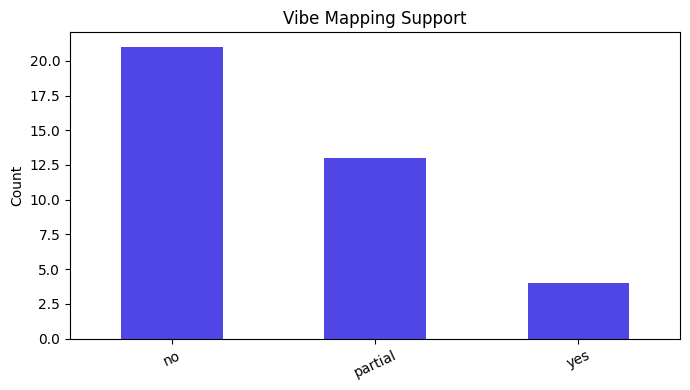

In [4]:
def bar_counts(series, title, filename, color="#4f46e5"):
    counts = series.value_counts().sort_index()
    ax = counts.plot(kind="bar", figsize=(7, 4), color=color)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=160)
    plt.show()

bar_counts(competitors["platform_group"], "Primary Platform Group", "platform-counts.png")
bar_counts(competitors["android_support"], "Android Support", "android-support.png")
bar_counts(competitors["ios_support"], "iOS Support", "ios-support.png")
bar_counts(competitors["web_support"], "Web Support", "web-support.png")
bar_counts(competitors["daw_output"], "DAW Output Support", "daw-output.png")
bar_counts(competitors["vibe_mapping"], "Vibe Mapping Support", "vibe-mapping.png")


## Competitor Categories

In [5]:
category_counts = competitors["category"].value_counts().rename_axis("category").reset_index(name="count")
category_counts


,category,count
0,ai_chord_generator,4
1,android_daw,3
2,ios_daw,2
3,chord_generator,1
4,midi_generator,1
5,ai_midi_generator,1
6,songwriting_theory_tool,1
7,ios_chord_generator,1
8,ios_chord_theory_tool,1
9,ios_theory_songwriting,1


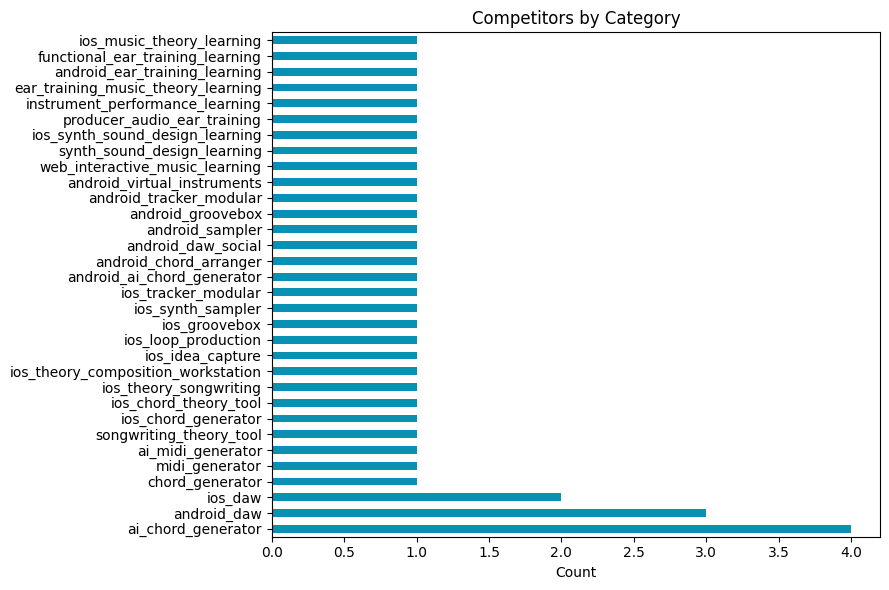

In [6]:
ax = category_counts.plot(kind="barh", x="category", y="count", legend=False, figsize=(9, 6), color="#0891b2")
ax.set_title("Competitors by Category")
ax.set_xlabel("Count")
ax.set_ylabel("")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "category-counts.png", dpi=160)
plt.show()


## Production vs Learning Coverage

This section separates production-only apps, learning-only apps, and production-plus-learning tools. Vibe-to-MIDI should compete mainly in `production_plus_learning` and `make_first_learning`, not as a generic DAW or generic lesson app.


In [7]:
mode_counts = competitors["product_mode"].value_counts().rename_axis("product_mode").reset_index(name="count")
mode_counts


,product_mode,count
0,production_only,18
1,production_plus_learning,13
2,learning_only,7


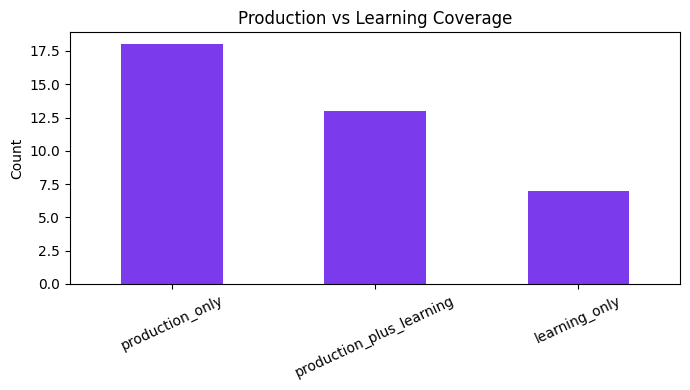

In [8]:
ax = mode_counts.plot(kind="bar", x="product_mode", y="count", legend=False, figsize=(7, 4), color="#7c3aed")
ax.set_title("Production vs Learning Coverage")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=25)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "production-learning-coverage.png", dpi=160)
plt.show()


In [9]:
make_first_refs = competitors[competitors["make_first_learning"].isin(["yes", "partial"])]
make_first_refs[["name", "platform_group", "product_mode", "category", "core_promise", "strengths", "gaps", "source_url"]].sort_values(["product_mode", "platform_group", "name"])


,name,platform_group,product_mode,category,core_promise,strengths,gaps,source_url
32,SoundGym,web,learning_only,producer_audio_ear_training,"Audio ear training games for frequency, compre...",producer-specific learning; gamified; progress...,"mixing/ear training, not composition; not vibe...",https://www.soundgym.co/
22,BandLab Android,android,production_only,android_daw_social,"Mobile DAW, virtual instruments, presets, AI t...",huge reach; free mobile DAW; instruments; AI t...,"broad studio, not vibe-to-note assistant; priv...",https://play.google.com/store/apps/details?id=...
20,Chordbot,android,production_only,android_chord_arranger,Create and play complex chord progressions and...,Android-native; MIDI export; arrangement patte...,not vibe-first; not electronic sound-design fo...,https://play.google.com/store/apps/details?id=...
28,Cubasis 3 Android,android,production_only,android_daw,"Mobile DAW with audio and MIDI editor, automat...",complete Android DAW; audio/MIDI editor; beat/...,DAW not assistant; high price; does not guide ...,https://play.google.com/store/apps/details?id=...
21,FL Studio Mobile,android,production_only,android_daw,Complete multitrack music projects with piano ...,full mobile DAW; MIDI import/export; piano rol...,does not solve what notes/chords/scales to cho...,https://play.google.com/store/apps/details?id=...
24,G-Stomper Studio,android,production_only,android_groovebox,"Step-sequencer groovebox, sampler, VA synth, A...",Android electronic powerhouse; MIDI in/out; Ab...,"complex production tool, not beginner decision...",https://play.google.com/store/apps/details?id=...
23,Koala Sampler Android,android,production_only,android_sampler,Fast pocket sampler for recording/importing so...,very fast flow; sampler-first; scales/swing; M...,sample/beat focused; not harmony/vibe-to-MIDI ...,https://play.google.com/store/apps/details?id=...
26,SunVox Android,android,production_only,android_tracker_modular,Modular synth/tracker with microtonal sequence...,advanced synthesis; MIDI import/export; genera...,steep learning curve; not a guided learning/de...,https://play.google.com/store/apps/details?id=...
27,Walk Band,android,production_only,android_virtual_instruments,"Virtual instruments, multitrack mixer, MIDI re...",large install base; virtual instruments; MIDI ...,instrument toolkit rather than vibe-to-DAW ass...,https://play.google.com/store/apps/details?id=...
25,n-Track Studio Android,android,production_only,android_daw,"Audio, instrument and beat tracks with loops, ...",Android DAW; audio/instrument/beat tracks; loo...,general DAW; not focused on note/chord choice ...,https://play.google.com/store/apps/details?id=...


## Platform x Capability Matrix

In [10]:
capability_fields = ["daw_output", "midi_export", "vibe_mapping", "electronic_music_fit", "learning_flow"]
platform_matrix = competitors.pivot_table(
    index="platform_group",
    values=["name"],
    aggfunc="count"
).rename(columns={"name": "count"})

for field in ["daw_output", "midi_export"]:
    platform_matrix[f"{field}_yes"] = competitors.assign(flag=competitors[field].eq("yes")).groupby("platform_group")["flag"].sum()

platform_matrix["vibe_mapping_yes_or_partial"] = competitors.assign(
    flag=competitors["vibe_mapping"].isin(["yes", "partial"])
).groupby("platform_group")["flag"].sum()

platform_matrix["high_electronic_fit"] = competitors.assign(
    flag=competitors["electronic_music_fit"].eq("high")
).groupby("platform_group")["flag"].sum()

platform_matrix


,count,daw_output_yes,midi_export_yes,vibe_mapping_yes_or_partial,high_electronic_fit
platform_group,,,,,
android,11,7,5,1,4
ios,14,10,6,7,9
ios_android,2,0,0,0,0
web,11,8,8,9,5


## Direct Competitors

Direct competitors have DAW output and explicit or partial vibe/mood mapping. These are most common on web and iOS. Android has fewer direct examples.

In [11]:
direct = competitors[(competitors["daw_output"] == "yes") & (competitors["vibe_mapping"].isin(["yes", "partial"]))]
direct[["name", "platform_group", "core_promise", "strengths", "gaps", "source_url"]].sort_values(["platform_group", "name"])


,name,platform_group,core_promise,strengths,gaps,source_url
19,AI Chord Generator,android,"AI chord progressions, melodies, piano-roll pr...",Android-native; mood/key/scale; piano roll; MI...,smaller/unclear traction; generic chord framin...,https://play.google.com/store/apps/details?id=...
13,Ableton Note,ios,"Start musical ideas, sample, sequence MIDI, an...",idea capture; curated sounds; MIDI editor; Abl...,iOS-only; not a theory or note-choice assistan...,https://apps.apple.com/us/app/ableton-note/id1...
14,Auxy Studio,ios,"Draw notes and drum patterns, arrange loops, s...",simple grid flow; strong electronic fit; expor...,iOS-first; not a theory explanation assistant;...,https://apps.apple.com/us/app/auxy-studio/id10...
8,Chord Progression Generator,ios,Generate chords and export chord/bass MIDI fil...,explicit EDM positioning; MIDI export; basslin...,iOS-only; chord progression tool rather than s...,https://apps.apple.com/us/app/chord-progressio...
15,Groovebox,ios,"Synth/drum studio with patterns, key/scale mod...",touch instruments; patterns; scale modes; Able...,"iOS-only; pattern/sound tool, not vibe-to-theo...",https://apps.apple.com/us/app/groovebox-beat-s...
9,OtoTheory / AI Chord Assistant,ios,"Chord progression builder with scale analysis,...",no-theory positioning; scale analysis; DAW-rea...,guitar/fretboard leaning; not club/electronic-...,https://apps.apple.com/us/app/ototheory/id6755...
11,Scaler 2 iPad,ios,"Detect key/scale and suggest chords, melodies,...",MIDI/audio detection; mood-based chord sets; b...,iPad-only legacy version; deep workstation com...,https://apps.apple.com/us/app/scaler-2/id16031...
1,ChordGen,web,Describe a mood and get chord progressions wit...,mood prompt; visual piano; edit/refine; free M...,web-first; harmony-focused; no mobile app work...,https://www.chordgen.org/
2,Chordoo,web,Generate genre chord progressions and export M...,free MIDI export; genre presets; no signup; DA...,less mood/vibe-specific; chord-only; no mobile...,https://www.chordoo.com/
4,GenChords,web,"Prompt the vibe, audition variations, and drag...",explicit vibe prompt; DAW-ready MIDI; position...,web-first; chord-centric; not Android-native,https://www.genchords.com/


## Android Gap Candidates

These Android tools show production demand, but most do not map vibe/mood to concrete musical choices.

In [12]:
android_gap = competitors[(competitors["android_support"] == "yes") & (~competitors["vibe_mapping"].isin(["yes", "partial"]))]
android_gap[["name", "category", "core_promise", "strengths", "gaps", "daw_output", "midi_export", "source_url"]]


,name,category,core_promise,strengths,gaps,daw_output,midi_export,source_url
18,SunVox iOS,ios_tracker_modular,"Modular synth, tracker sequencer, MIDI import/...",powerful modular/tracker; MIDI import/export; ...,steep learning curve; not beginner/vibe-orient...,yes,yes,https://apps.apple.com/us/app/sunvox/id324462544
20,Chordbot,android_chord_arranger,Create and play complex chord progressions and...,Android-native; MIDI export; arrangement patte...,not vibe-first; not electronic sound-design fo...,yes,yes,https://play.google.com/store/apps/details?id=...
21,FL Studio Mobile,android_daw,Complete multitrack music projects with piano ...,full mobile DAW; MIDI import/export; piano rol...,does not solve what notes/chords/scales to cho...,yes,yes,https://play.google.com/store/apps/details?id=...
22,BandLab Android,android_daw_social,"Mobile DAW, virtual instruments, presets, AI t...",huge reach; free mobile DAW; instruments; AI t...,"broad studio, not vibe-to-note assistant; priv...",partial,partial,https://play.google.com/store/apps/details?id=...
23,Koala Sampler Android,android_sampler,Fast pocket sampler for recording/importing so...,very fast flow; sampler-first; scales/swing; M...,sample/beat focused; not harmony/vibe-to-MIDI ...,partial,partial,https://play.google.com/store/apps/details?id=...
24,G-Stomper Studio,android_groovebox,"Step-sequencer groovebox, sampler, VA synth, A...",Android electronic powerhouse; MIDI in/out; Ab...,"complex production tool, not beginner decision...",yes,yes,https://play.google.com/store/apps/details?id=...
25,n-Track Studio Android,android_daw,"Audio, instrument and beat tracks with loops, ...",Android DAW; audio/instrument/beat tracks; loo...,general DAW; not focused on note/chord choice ...,yes,partial,https://play.google.com/store/apps/details?id=...
26,SunVox Android,android_tracker_modular,Modular synth/tracker with microtonal sequence...,advanced synthesis; MIDI import/export; genera...,steep learning curve; not a guided learning/de...,yes,yes,https://play.google.com/store/apps/details?id=...
27,Walk Band,android_virtual_instruments,"Virtual instruments, multitrack mixer, MIDI re...",large install base; virtual instruments; MIDI ...,instrument toolkit rather than vibe-to-DAW ass...,partial,partial,https://play.google.com/store/apps/details?id=...
28,Cubasis 3 Android,android_daw,"Mobile DAW with audio and MIDI editor, automat...",complete Android DAW; audio/MIDI editor; beat/...,DAW not assistant; high price; does not guide ...,yes,partial,https://play.google.com/store/apps/details?id=...


## Make-First References

In [13]:
make_first = competitors[competitors["learning_flow"].eq("make_to_learn")]
make_first[["name", "platform_group", "category", "core_promise", "electronic_music_fit", "source_url"]].sort_values(["platform_group", "name"])


,name,platform_group,category,core_promise,electronic_music_fit,source_url
19,AI Chord Generator,android,android_ai_chord_generator,"AI chord progressions, melodies, piano-roll pr...",medium,https://play.google.com/store/apps/details?id=...
22,BandLab Android,android,android_daw_social,"Mobile DAW, virtual instruments, presets, AI t...",medium,https://play.google.com/store/apps/details?id=...
20,Chordbot,android,android_chord_arranger,Create and play complex chord progressions and...,medium,https://play.google.com/store/apps/details?id=...
28,Cubasis 3 Android,android,android_daw,"Mobile DAW with audio and MIDI editor, automat...",medium,https://play.google.com/store/apps/details?id=...
21,FL Studio Mobile,android,android_daw,Complete multitrack music projects with piano ...,high,https://play.google.com/store/apps/details?id=...
24,G-Stomper Studio,android,android_groovebox,"Step-sequencer groovebox, sampler, VA synth, A...",high,https://play.google.com/store/apps/details?id=...
23,Koala Sampler Android,android,android_sampler,Fast pocket sampler for recording/importing so...,high,https://play.google.com/store/apps/details?id=...
26,SunVox Android,android,android_tracker_modular,Modular synth/tracker with microtonal sequence...,high,https://play.google.com/store/apps/details?id=...
27,Walk Band,android,android_virtual_instruments,"Virtual instruments, multitrack mixer, MIDI re...",low,https://play.google.com/store/apps/details?id=...
25,n-Track Studio Android,android,android_daw,"Audio, instrument and beat tracks with loops, ...",medium,https://play.google.com/store/apps/details?id=...


## Keyword Seeds

In [14]:
keywords

,intent,keyword,language,notes,region,relative_interest,source,trend_direction
0,direct concept,vibe to midi,en,Likely niche phrase; validate search volume.,global,,manual_seed,unknown
1,direct concept,mood to midi,en,Core product language candidate.,global,,manual_seed,unknown
2,solution aware,AI chord progression generator,en,Crowded web competitor space.,global,,manual_seed,competitive
3,solution aware,chord progression generator MIDI,en,Common existing workflow.,global,,manual_seed,competitive
4,problem aware,music theory for producers,en,Learning-oriented angle.,global,,manual_seed,stable
5,genre specific,techno bassline generator,en,Useful for club music positioning.,global,,manual_seed,unknown
6,genre specific,melodic techno chords,en,Likely content/MVP tag candidate.,global,,manual_seed,unknown
7,problem aware,how to make dark techno,en,Maps to dark/underground tag.,global,,manual_seed,unknown
8,problem aware,DTM コード進行,ja,Japanese secondary market keyword.,jp,,manual_seed,unknown
9,pain expression,作曲 コード わからない,ja,Direct pain phrasing.,jp,,manual_seed,unknown


## Platform Decision Frame

This research should compare Web, iOS, and Android without assuming the answer.

Decision criteria:

- validation speed
- implementation cost
- audio preview feasibility
- distribution friction
- competitive density
- fit with DAW/music-production workflows
- ability to later support MIDI, local AI, or desktop integration

Initial read from the current sample:

- Web has the lowest distribution friction, but more direct mood-to-MIDI/chord competitors.
- iOS has strong make-first music apps and polished production references, but stronger competition and Apple distribution constraints.
- Android may have a thinner vibe-to-DAW assistant layer, but audio/MIDI implementation risk must be checked before committing to it.


## Decision Summary

Decision: **Narrow / Build after platform choice is validated**.

The broader sample changes the interpretation. The platform choice should not assume Android by default. Android has many capable production tools. The clearer gap is:

> Android has fewer focused tools that translate a desired vibe into DAW-ready scale, chord, bass, rhythm, and sound-design decisions.

Web already has multiple AI/vibe-to-chord/MIDI competitors. iOS has stronger polished make-first references and richer theory/chord tools. Android has serious DAWs and grooveboxes, but the assistant layer is thinner.

Regardless of platform, Phase 1 should include:

- vibe tag selection
- generated audio preview
- club-music-oriented scale/chord/bass/rhythm suggestions
- sound design hints
- copyable note/chord output

Defer MIDI export to Phase 2 unless further user research finds that export is the primary adoption trigger.


## Positioning

Avoid: generic AI music generation, generic chord progression generation, or lesson-first theory training.

Use:

> A make-first production-and-learning assistant that turns vibe into DAW-ready musical choices, then explains why those choices work.


## Open Questions

- Is Android audio latency acceptable for interactive preview, or should MVP playback be simple sequenced playback?
- Which Android DAW/export workflow matters most: FL Studio Mobile, BandLab, Cubasis, G-Stomper, or generic note copying?
- Is MIDI export required for trust, or can copyable DAW guidance validate the first MVP?
- Which term tests better: Vibe-to-MIDI, Mood-to-MIDI, Vibe Notes, or Vibe Producing?
- Should iOS remain a later target given the stronger existing make-first ecosystem?
